# Frequent Itemset Mining — Apriori Algorithm

**Dataset**: Synthetic grocery market basket (1000 transactions, 20 items)  
**Objective**: Mine frequent itemsets and association rules, then analyse how performance changes under various support and confidence thresholds.

### Key Concepts

| Term | Definition |
|---|---|
| **Itemset** | Any subset of items appearing in transactions |
| **Support** | $\text{supp}(X) = \frac{\text{transactions containing } X}{\text{total transactions}}$ |
| **Confidence** | $\text{conf}(X \Rightarrow Y) = \frac{\text{supp}(X \cup Y)}{\text{supp}(X)}$ |
| **Lift** | $\text{lift}(X \Rightarrow Y) = \frac{\text{conf}(X \Rightarrow Y)}{\text{supp}(Y)}$ — lift > 1 means positive correlation |
| **Frequent Itemset** | An itemset whose support ≥ min\_support threshold |
| **Association Rule** | $X \Rightarrow Y$ — if a customer buys $X$, they likely also buy $Y$ |



| Section | Description |
|---|---|
| 1 | Dataset — Market Basket Transactions |
| 2 | Preprocessing — One-Hot Encoding |
| 3 | Frequent Itemset Mining (Apriori) |
| 4 | Association Rule Generation |
| 5 | Performance Analysis — Varying Support |
| 6 | Performance Analysis — Varying Confidence |
| 7 | Performance Heatmap — Support × Confidence |
| 8 | Top Rules Visualisation |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
import warnings
warnings.filterwarnings('ignore')

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

np.random.seed(42)
print('All imports successful.')

All imports successful.


## 1. Dataset — Market Basket Transactions

A synthetic grocery store dataset is generated with realistic purchase probabilities.  
Items are grouped into natural co-purchase clusters (e.g. bread + butter + milk) to produce meaningful association rules.

In [3]:
ITEMS = [
    'bread', 'butter', 'milk', 'eggs', 'cheese',
    'yogurt', 'coffee', 'tea', 'sugar', 'flour',
    'chicken', 'beef', 'fish', 'pasta', 'rice',
    'tomato', 'onion', 'garlic', 'apple', 'banana'
]

# Base probability each item appears in a transaction
BASE_PROB = {
    'bread': 0.55, 'butter': 0.40, 'milk': 0.50, 'eggs': 0.45, 'cheese': 0.35,
    'yogurt': 0.30, 'coffee': 0.45, 'tea': 0.35, 'sugar': 0.40, 'flour': 0.25,
    'chicken': 0.35, 'beef': 0.30, 'fish': 0.25, 'pasta': 0.35, 'rice': 0.40,
    'tomato': 0.45, 'onion': 0.50, 'garlic': 0.45, 'apple': 0.35, 'banana': 0.40
}

# Co-purchase clusters: buying item A boosts probability of item B
CORRELATIONS = [
    (['bread', 'butter'], 0.6),
    (['milk', 'eggs', 'cheese'], 0.5),
    (['coffee', 'sugar', 'milk'], 0.55),
    (['pasta', 'tomato', 'garlic', 'onion'], 0.6),
    (['rice', 'chicken', 'garlic', 'onion'], 0.55),
    (['flour', 'sugar', 'eggs', 'butter'], 0.5),
]

N_TRANSACTIONS = 1000
transactions = []

for _ in range(N_TRANSACTIONS):
    probs = dict(BASE_PROB)
    # Apply correlation boosts based on randomly triggered clusters
    for cluster, boost in CORRELATIONS:
        if np.random.rand() < 0.4:
            for item in cluster:
                probs[item] = min(1.0, probs[item] + boost)
    basket = [item for item in ITEMS if np.random.rand() < probs[item]]
    if basket:  # skip empty baskets
        transactions.append(basket)

print(f'Total transactions  : {len(transactions)}')
print(f'Avg basket size     : {np.mean([len(t) for t in transactions]):.2f} items')
print(f'Min / Max basket    : {min(len(t) for t in transactions)} / {max(len(t) for t in transactions)}')
print(f'\nSample transactions:')
for t in transactions[:5]:
    print(' ', t)

Total transactions  : 1000
Avg basket size     : 11.45 items
Min / Max basket    : 3 / 18

Sample transactions:
  ['bread', 'butter', 'eggs', 'cheese', 'tea', 'sugar', 'flour', 'chicken', 'pasta', 'rice', 'tomato', 'onion', 'garlic']
  ['bread', 'butter', 'eggs', 'cheese', 'yogurt', 'sugar', 'flour', 'chicken', 'pasta', 'rice', 'tomato', 'onion', 'garlic']
  ['bread', 'butter', 'milk', 'eggs', 'coffee', 'sugar', 'chicken', 'pasta', 'rice', 'onion', 'garlic', 'banana']
  ['bread', 'butter', 'milk', 'eggs', 'coffee', 'sugar', 'flour', 'chicken', 'rice', 'tomato', 'onion', 'garlic', 'apple']
  ['bread', 'butter', 'milk', 'eggs', 'cheese', 'tea', 'sugar', 'flour', 'chicken', 'pasta', 'rice', 'tomato', 'onion', 'garlic', 'apple']


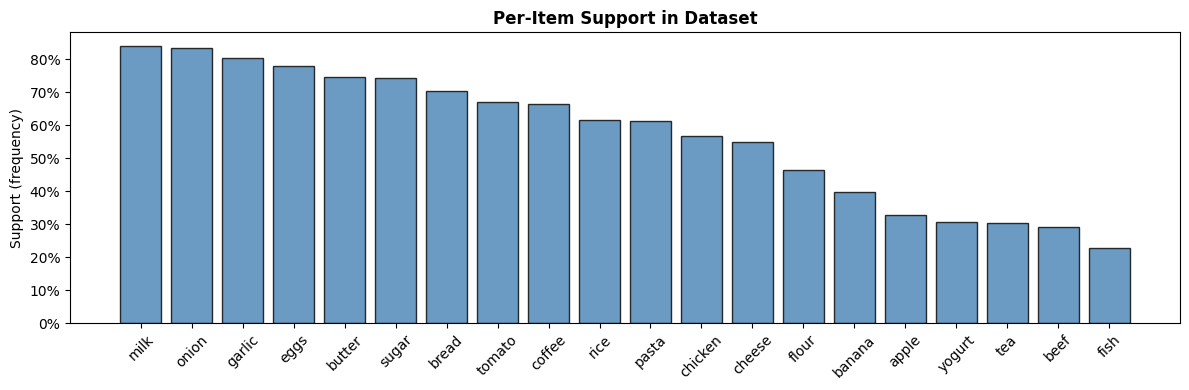

In [4]:
# Item frequency overview
from collections import Counter
item_counts = Counter(item for t in transactions for item in t)
items_sorted = sorted(item_counts.items(), key=lambda x: -x[1])

labels, counts = zip(*items_sorted)
freqs = [c / len(transactions) for c in counts]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(labels, freqs, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_ylabel('Support (frequency)')
ax.set_title('Per-Item Support in Dataset', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 2. Preprocessing — One-Hot Encoding

The Apriori algorithm requires a binary (one-hot encoded) transaction matrix where each column is an item and each row is a transaction.

In [5]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Encoded matrix shape: {df.shape}  (transactions × items)')
print(f'\nFirst 5 rows (True = item present):')
df.head()

Encoded matrix shape: (1000, 20)  (transactions × items)

First 5 rows (True = item present):


,apple,banana,beef,bread,butter,cheese,chicken,coffee,eggs,fish,flour,garlic,milk,onion,pasta,rice,sugar,tea,tomato,yogurt
0,False,False,False,True,True,True,True,False,True,False,True,True,False,True,True,True,True,True,True,False
1,False,False,False,True,True,True,True,False,True,False,True,True,False,True,True,True,True,False,True,True
2,False,True,False,True,True,False,True,True,True,False,False,True,True,True,True,True,True,False,False,False
3,True,False,False,True,True,False,True,True,True,False,True,True,True,True,False,True,True,False,True,False
4,True,False,False,True,True,True,True,False,True,False,True,True,True,True,True,True,True,True,True,False


## 3. Frequent Itemset Mining — Apriori

Run Apriori with `min_support = 0.3` as a baseline to find all itemsets that appear in at least 30% of transactions.

In [6]:
MIN_SUPPORT = 0.3

t0 = time.time()
frequent_itemsets = apriori(df, min_support=MIN_SUPPORT, use_colnames=True)
elapsed = time.time() - t0

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets.sort_values('support', ascending=False, inplace=True)
frequent_itemsets.reset_index(drop=True, inplace=True)

print(f'min_support = {MIN_SUPPORT}  |  Time: {elapsed:.4f}s')
print(f'Total frequent itemsets found: {len(frequent_itemsets)}')
print()
print('By itemset size:')
print(frequent_itemsets['length'].value_counts().sort_index().rename('count').to_string())
print()
print('Top 10 by support:')
frequent_itemsets[['support', 'itemsets']].head(10)

min_support = 0.3  |  Time: 0.0305s
Total frequent itemsets found: 617

By itemset size:
length
1     18
2     90
3    236
4    213
5     59
6      1

Top 10 by support:


,support,itemsets
0,0.840,frozenset({milk})
1,0.834,frozenset({onion})
2,0.804,frozenset({garlic})
3,0.779,frozenset({eggs})
4,0.747,frozenset({butter})
5,0.743,frozenset({sugar})
6,0.729,"frozenset({onion, garlic})"
7,0.705,frozenset({bread})
8,0.696,"frozenset({milk, onion})"
9,0.676,"frozenset({milk, garlic})"


## 4. Association Rule Generation

From the frequent itemsets, generate association rules filtered by `min_confidence = 0.5`.

In [7]:
MIN_CONFIDENCE = 0.5

rules = association_rules(frequent_itemsets, metric='confidence',
                          min_threshold=MIN_CONFIDENCE, num_itemsets=len(frequent_itemsets))
rules.sort_values('lift', ascending=False, inplace=True)
rules.reset_index(drop=True, inplace=True)

print(f'Total rules generated : {len(rules)}')
print(f'\nTop 10 rules by lift:')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Total rules generated : 5074

Top 10 rules by lift:


,antecedents,consequents,support,confidence,lift
0,"frozenset({onion, tomato, milk})","frozenset({garlic, pasta, eggs})",0.307,0.611554,1.487965
1,"frozenset({garlic, pasta, eggs})","frozenset({onion, tomato, milk})",0.307,0.746959,1.487965
2,"frozenset({onion, tomato})","frozenset({garlic, pasta, eggs})",0.349,0.587542,1.429543
3,"frozenset({garlic, pasta, eggs})","frozenset({onion, tomato})",0.349,0.849148,1.429543
4,"frozenset({garlic, pasta})","frozenset({onion, tomato, milk})",0.386,0.717472,1.429227
5,"frozenset({onion, tomato, milk})","frozenset({garlic, pasta})",0.386,0.768924,1.429227
6,"frozenset({butter, garlic, pasta})","frozenset({onion, tomato})",0.339,0.845387,1.423210
7,"frozenset({onion, tomato})","frozenset({butter, garlic, pasta})",0.339,0.570707,1.423210
8,"frozenset({onion, eggs, tomato})","frozenset({milk, garlic, pasta})",0.307,0.661638,1.422877
9,"frozenset({milk, garlic, pasta})","frozenset({onion, eggs, tomato})",0.307,0.660215,1.422877


## 5. Performance Analysis — Varying Support

As `min_support` **decreases**, the algorithm must consider more itemsets — exponentially increasing both the number of results and the runtime.

In [8]:
support_values = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]
support_results = []

for supp in support_values:
    t0 = time.time()
    fi = apriori(df, min_support=supp, use_colnames=True)
    elapsed = time.time() - t0
    fi['length'] = fi['itemsets'].apply(len)
    support_results.append({
        'min_support': supp,
        'n_itemsets': len(fi),
        'n_1_itemsets': (fi['length'] == 1).sum(),
        'n_2_itemsets': (fi['length'] == 2).sum(),
        'n_3plus_itemsets': (fi['length'] >= 3).sum(),
        'time_s': elapsed
    })
    print(f'  support={supp:.2f} → {len(fi):4d} itemsets  ({elapsed:.4f}s)')

supp_df = pd.DataFrame(support_results)

  support=0.50 →   71 itemsets  (0.0102s)
  support=0.45 →  121 itemsets  (0.0102s)
  support=0.40 →  198 itemsets  (0.0086s)
  support=0.35 →  355 itemsets  (0.0141s)
  support=0.30 →  617 itemsets  (0.0228s)
  support=0.25 → 1119 itemsets  (0.0417s)
  support=0.20 → 2130 itemsets  (0.0642s)
  support=0.15 → 4358 itemsets  (0.3804s)
  support=0.10 → 10181 itemsets  (0.4154s)


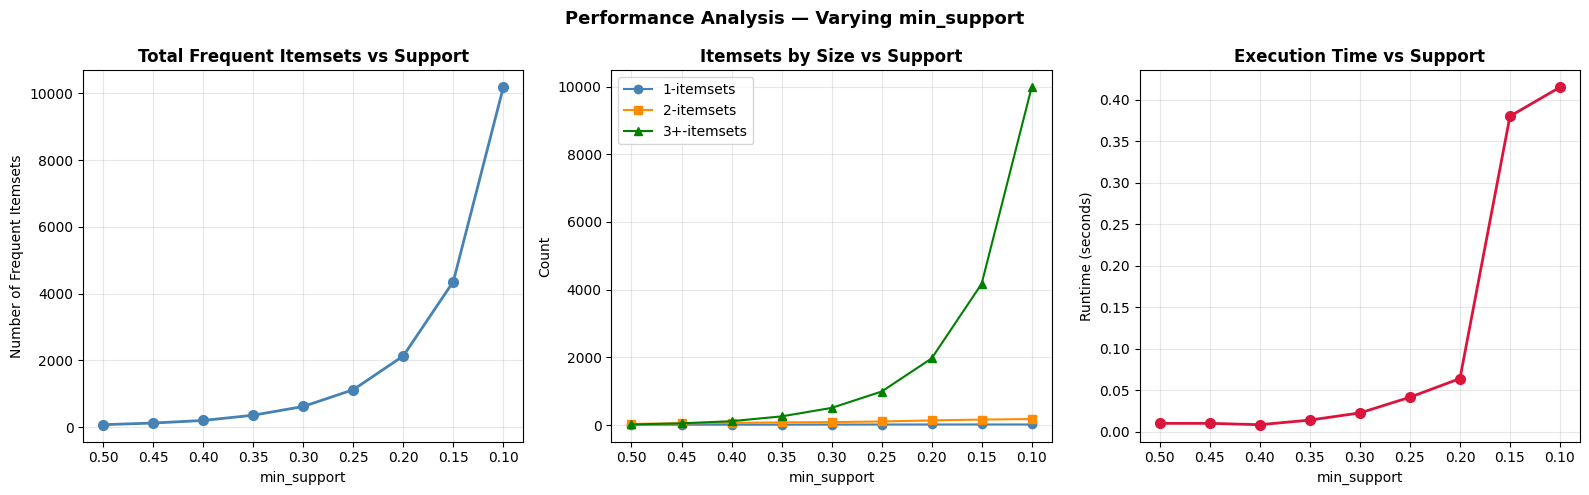

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Total itemsets
ax = axes[0]
ax.plot(supp_df['min_support'], supp_df['n_itemsets'], 'o-', color='steelblue', lw=2, markersize=7)
ax.set_xlabel('min_support')
ax.set_ylabel('Number of Frequent Itemsets')
ax.set_title('Total Frequent Itemsets vs Support', fontweight='bold')
ax.invert_xaxis()
ax.grid(alpha=0.3)

# Itemsets by size
ax = axes[1]
ax.plot(supp_df['min_support'], supp_df['n_1_itemsets'],  'o-', label='1-itemsets', color='steelblue')
ax.plot(supp_df['min_support'], supp_df['n_2_itemsets'],  's-', label='2-itemsets', color='darkorange')
ax.plot(supp_df['min_support'], supp_df['n_3plus_itemsets'], '^-', label='3+-itemsets', color='green')
ax.set_xlabel('min_support')
ax.set_ylabel('Count')
ax.set_title('Itemsets by Size vs Support', fontweight='bold')
ax.invert_xaxis()
ax.legend()
ax.grid(alpha=0.3)

# Runtime
ax = axes[2]
ax.plot(supp_df['min_support'], supp_df['time_s'], 'o-', color='crimson', lw=2, markersize=7)
ax.set_xlabel('min_support')
ax.set_ylabel('Runtime (seconds)')
ax.set_title('Execution Time vs Support', fontweight='bold')
ax.invert_xaxis()
ax.grid(alpha=0.3)

plt.suptitle('Performance Analysis — Varying min_support', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Performance Analysis — Varying Confidence

Keeping `min_support` fixed at 0.2, we vary `min_confidence` and count how many association rules survive each threshold.

In [10]:
# Mine once at low support so we have enough itemsets to filter
fi_base = apriori(df, min_support=0.2, use_colnames=True)

confidence_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
conf_results = []

for conf in confidence_values:
    r = association_rules(fi_base, metric='confidence',
                          min_threshold=conf, num_itemsets=len(fi_base))
    conf_results.append({
        'min_confidence': conf,
        'n_rules': len(r),
        'avg_lift': r['lift'].mean() if len(r) > 0 else 0,
        'avg_support': r['support'].mean() if len(r) > 0 else 0
    })
    print(f'  confidence={conf:.1f} → {len(r):4d} rules  |  avg lift={r["lift"].mean():.3f}' if len(r) > 0
          else f'  confidence={conf:.1f} → 0 rules')

conf_df = pd.DataFrame(conf_results)

  confidence=0.3 → 45184 rules  |  avg lift=1.125
  confidence=0.4 → 37041 rules  |  avg lift=1.130
  confidence=0.5 → 26987 rules  |  avg lift=1.132
  confidence=0.6 → 17353 rules  |  avg lift=1.131
  confidence=0.7 → 9980 rules  |  avg lift=1.130
  confidence=0.8 → 4478 rules  |  avg lift=1.122
  confidence=0.9 → 1410 rules  |  avg lift=1.143


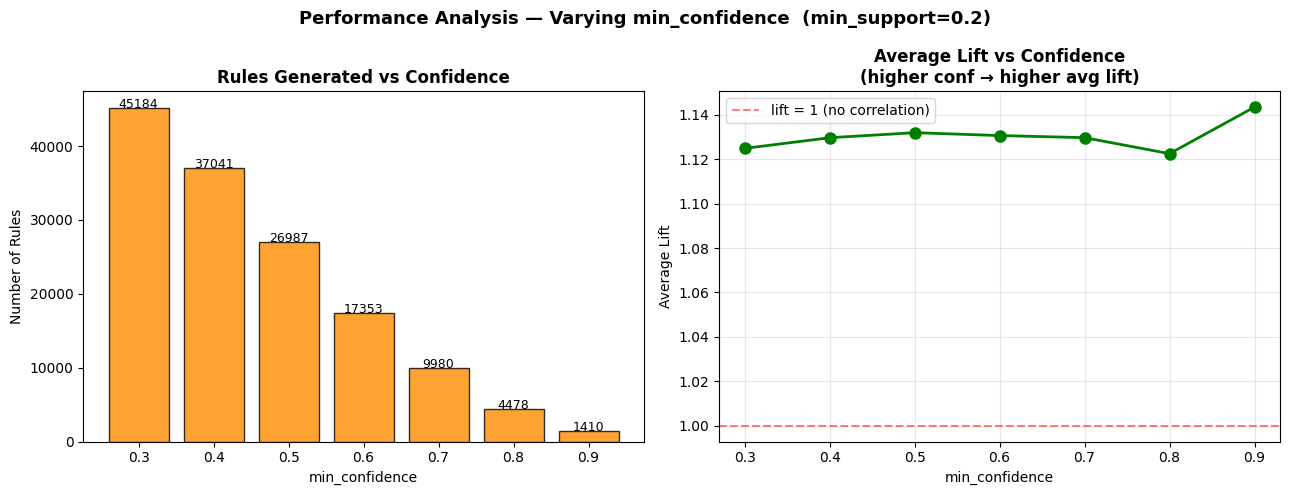

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Rules count
ax = axes[0]
ax.bar(conf_df['min_confidence'].astype(str), conf_df['n_rules'],
       color='darkorange', alpha=0.8, edgecolor='black')
for i, v in enumerate(conf_df['n_rules']):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
ax.set_xlabel('min_confidence')
ax.set_ylabel('Number of Rules')
ax.set_title('Rules Generated vs Confidence', fontweight='bold')

# Avg lift
ax = axes[1]
ax.plot(conf_df['min_confidence'], conf_df['avg_lift'], 'o-',
        color='green', lw=2, markersize=8)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='lift = 1 (no correlation)')
ax.set_xlabel('min_confidence')
ax.set_ylabel('Average Lift')
ax.set_title('Average Lift vs Confidence\n(higher conf → higher avg lift)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Performance Analysis — Varying min_confidence  (min_support=0.2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Performance Heatmap — Support × Confidence

A grid search over both thresholds simultaneously to see how the **number of rules** changes across the full parameter space.

In [12]:
supp_grid = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
conf_grid = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Cache frequent itemsets per support value
fi_cache = {}
for s in supp_grid:
    fi_cache[s] = apriori(df, min_support=s, use_colnames=True)

# Build heatmap matrices
n_rules_grid = np.zeros((len(supp_grid), len(conf_grid)), dtype=int)
time_grid    = np.zeros((len(supp_grid), len(conf_grid)))

for i, s in enumerate(supp_grid):
    for j, c in enumerate(conf_grid):
        t0 = time.time()
        r = association_rules(fi_cache[s], metric='confidence',
                              min_threshold=c, num_itemsets=len(fi_cache[s]))
        time_grid[i, j] = time.time() - t0
        n_rules_grid[i, j] = len(r)

print('Heatmap computed.')

Heatmap computed.


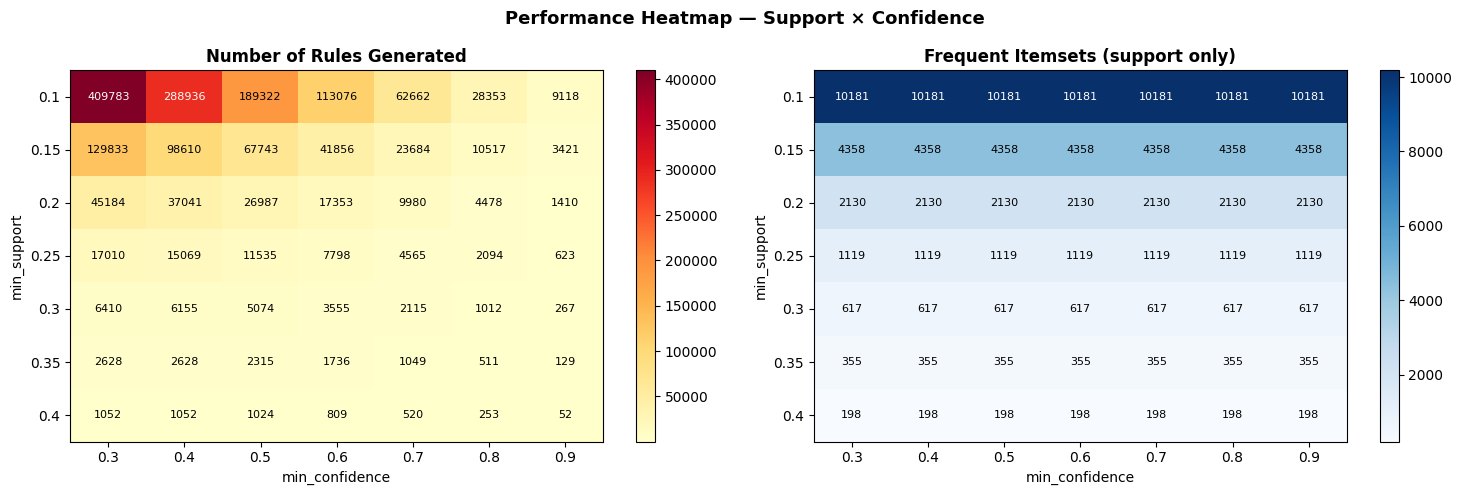

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

conf_labels = [str(c) for c in conf_grid]
supp_labels = [str(s) for s in supp_grid]

# Rules heatmap
ax = axes[0]
im = ax.imshow(n_rules_grid, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(conf_grid)))
ax.set_xticklabels(conf_labels)
ax.set_yticks(range(len(supp_grid)))
ax.set_yticklabels(supp_labels)
ax.set_xlabel('min_confidence')
ax.set_ylabel('min_support')
ax.set_title('Number of Rules Generated', fontweight='bold')
plt.colorbar(im, ax=ax)
for i in range(len(supp_grid)):
    for j in range(len(conf_grid)):
        ax.text(j, i, str(n_rules_grid[i, j]),
                ha='center', va='center', fontsize=8,
                color='black' if n_rules_grid[i, j] < n_rules_grid.max() * 0.6 else 'white')

# Frequent itemsets heatmap
fi_counts = np.array([len(fi_cache[s]) for s in supp_grid]).reshape(-1, 1)
fi_grid   = np.tile(fi_counts, (1, len(conf_grid)))

ax = axes[1]
im2 = ax.imshow(fi_grid, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(conf_grid)))
ax.set_xticklabels(conf_labels)
ax.set_yticks(range(len(supp_grid)))
ax.set_yticklabels(supp_labels)
ax.set_xlabel('min_confidence')
ax.set_ylabel('min_support')
ax.set_title('Frequent Itemsets (support only)', fontweight='bold')
plt.colorbar(im2, ax=ax)
for i in range(len(supp_grid)):
    for j in range(len(conf_grid)):
        ax.text(j, i, str(fi_counts[i, 0]),
                ha='center', va='center', fontsize=8,
                color='black' if fi_counts[i, 0] < fi_counts.max() * 0.6 else 'white')

plt.suptitle('Performance Heatmap — Support × Confidence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Top Rules Visualisation

Scatter plot of all rules (support vs confidence, bubble size = lift) to identify the strongest rules at a glance.

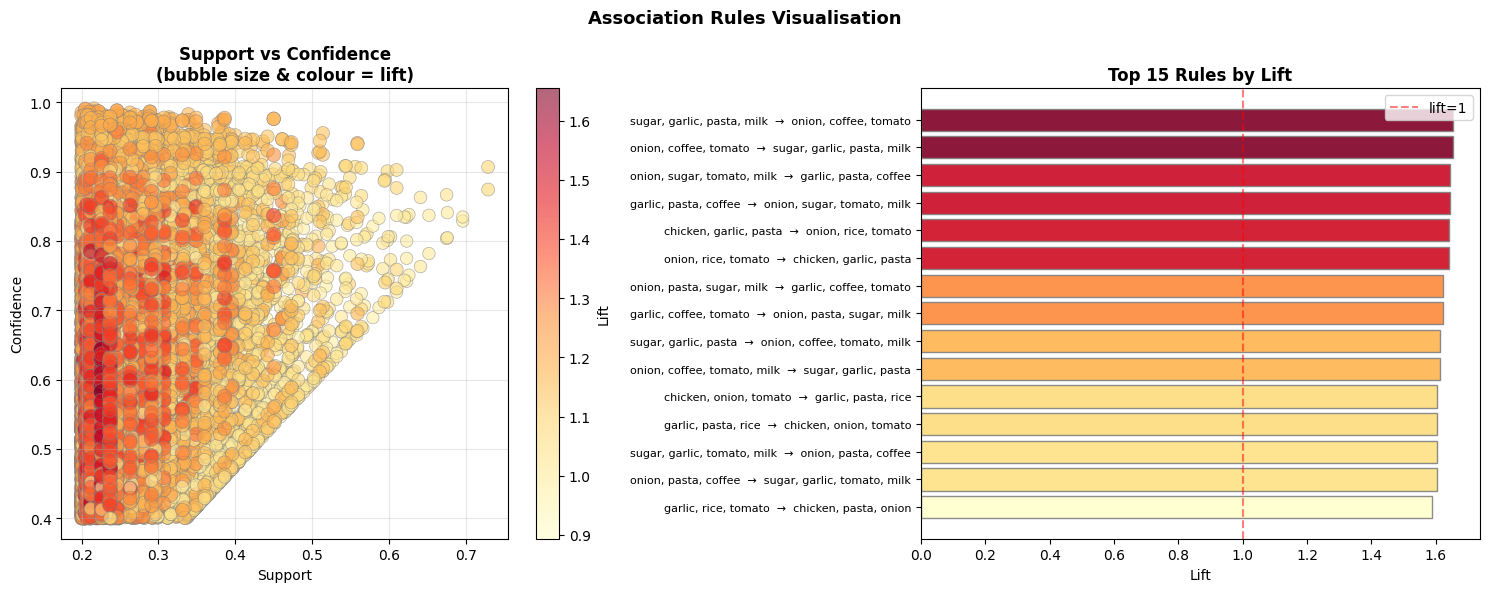

Total rules shown: 37041
Max lift: 1.655
Avg lift: 1.130


In [14]:
# Use a moderately permissive threshold to get a meaningful set of rules
fi_plot = apriori(df, min_support=0.2, use_colnames=True)
rules_plot = association_rules(fi_plot, metric='confidence',
                               min_threshold=0.4, num_itemsets=len(fi_plot))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Support vs Confidence scatter (bubble = lift)
ax = axes[0]
sc = ax.scatter(
    rules_plot['support'], rules_plot['confidence'],
    s=rules_plot['lift'] * 80, alpha=0.6,
    c=rules_plot['lift'], cmap='YlOrRd', edgecolors='grey', linewidths=0.5
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Support vs Confidence\n(bubble size & colour = lift)', fontweight='bold')
ax.grid(alpha=0.3)

# Top 15 rules by lift — horizontal bar chart
ax = axes[1]
top15 = rules_plot.nlargest(15, 'lift').copy()
top15['rule'] = [
    f"{', '.join(list(ant))}  →  {', '.join(list(con))}"
    for ant, con in zip(top15['antecedents'], top15['consequents'])
]
colors_bar = plt.cm.YlOrRd(
    (top15['lift'] - top15['lift'].min()) /
    (top15['lift'].max() - top15['lift'].min() + 1e-9)
)
bars = ax.barh(top15['rule'][::-1], top15['lift'][::-1],
               color=colors_bar[::-1], edgecolor='grey', alpha=0.9)
ax.set_xlabel('Lift')
ax.set_title('Top 15 Rules by Lift', fontweight='bold')
ax.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='lift=1')
ax.legend()
ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Association Rules Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total rules shown: {len(rules_plot)}')
print(f'Max lift: {rules_plot["lift"].max():.3f}')
print(f'Avg lift: {rules_plot["lift"].mean():.3f}')

## Summary

| Parameter | Effect on Itemsets | Effect on Rules | Effect on Runtime |
|---|---|---|---|
| **↓ min_support** | Grows rapidly (exponential) | More rules available | Increases significantly |
| **↑ min_support** | Shrinks — only very common itemsets | Fewer rules | Faster |
| **↓ min_confidence** | No effect (post-processing) | More rules, lower avg lift | Negligible |
| **↑ min_confidence** | No effect (post-processing) | Fewer but stronger rules, higher avg lift | Negligible |

**Key observations:**
- `min_support` is the critical bottleneck — lowering it causes an exponential blowup in candidate itemsets
- `min_confidence` is cheap to vary: rules are filtered *after* mining, so it only affects rule count, not mining time
- High-lift rules (lift > 1) indicate genuine co-purchase behaviour beyond chance (e.g. pasta → tomato, coffee → sugar)
- A practical threshold choice is `min_support ≈ 0.2–0.3` and `min_confidence ≈ 0.5–0.6` for a manageable, high-quality ruleset